In [ ]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys #首先，添加路径，windows的路径和linux的路径符号不同\\,/,注意区别  #r是为了告诉python这是路径，别#把\n等特殊组合给转译）
sys.path.append(r"./main_code")
import generate_data2,grid_cell,adaptive_int_fix,visual,cal_S_grad,org_m,mea_2D,net_2D_shape,S_valgrad,error_general_ada,main,ass_grad,main_fix
CUDA_LAUNCH_BLOCKING=1
def f_circle(x,x_left,x_right,y_below,y_upper,center,r):
    # Compute r_y = sqrt((x1 - y1)^2 + (x2 - y2)^2 + (x3 - y3)^2)
    r_y = np.linalg.norm(x - center, axis=-1)
    # Apply the piecewise function
    f_y_values = np.where(r_y < r , 1.0, 0.0)
    return f_y_values

cuda:0


In [ ]:
from importlib import reload
reload(grid_cell)

In [3]:
import copy
Nx,Ny=1,1
Ix,Iy=4,4  #x方向网格点
nx,ny=3,3  #每个网格x方向的高斯点
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89]
tau_x_min,tau_x_max,tau_y_min,tau_y_max=0,1,0,1
b_x_min,b_x_max,b_y_min,b_y_max=-0.5,1.5,-0.5,1.5 #边界gamma处

num_batches_gauss=1
b_n=15
points_b=mea_2D.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n) #在边界Γ处收集数据
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.2
center_true=np.array([0.5,0.5])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
cupy_device=0
S_int_true_circle,F_mea_b_circle,F_mea_db_x1_circle,F_mea_db_x2_circle=generate_data2.boundary_data_circle(kk,number_gene,points_b,f_circle,x_left,x_right,y_below,y_upper,center_true,r_true,eps,mea,batch_number_rec_mea,device,cupy_device)
F=org_m.F(F_mea_b_circle,F_mea_db_x1_circle,F_mea_db_x2_circle)

cells= grid_cell.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b) #创造初始网格
initial_cells=copy.deepcopy(cells) #copy一份
R_m=20
r_low,r_upper=0.18,0.2
b_below,b_upper=-0.51,-0.49

In [4]:
M=3200
af="Tanh"   #先用tanh
R_m=20
cupy_device= 0

#models = net_2D_shape.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
models = net_2D_shape.local_rep(2,1,1,M,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],R_m_for_init=R_m,af=af,Shape=[],device=device).to(device)

In [ ]:
from importlib import reload
from re import S    
reload(main_fix)
reload(adaptive_int_fix)
reload(S_valgrad)

/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


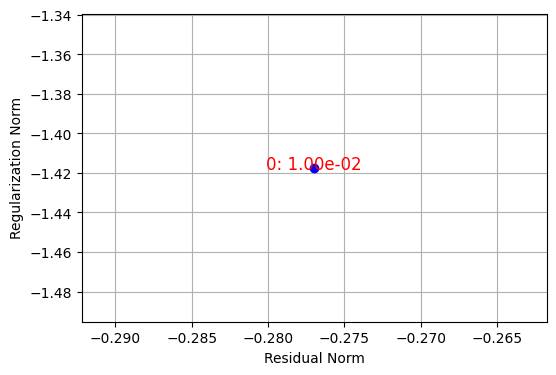

第 0 次迭代的train误差：


/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/torch/autograd/graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


第 0 次迭代的泛化误差：


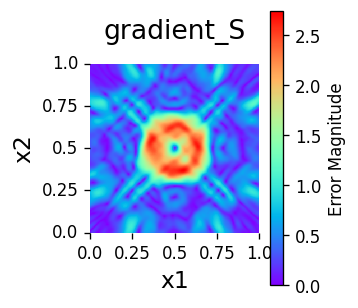

S_l_inf= 2.7249492478534134 S_L_2= 0.2880784421710187 S_l_2= 0.8163285044055826


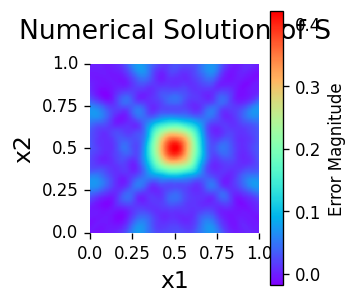

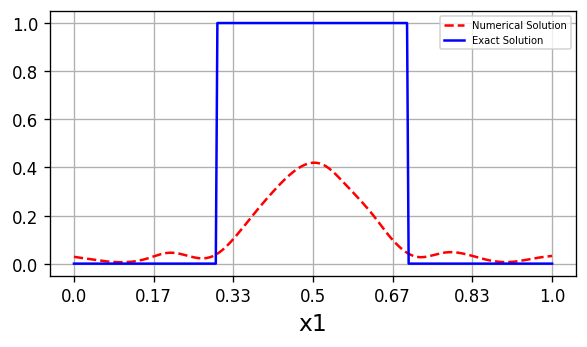

第 0 次自适应网格细分 (Diff Criterion)...
Generating visualizations...
1. Plotting mesh comparison...


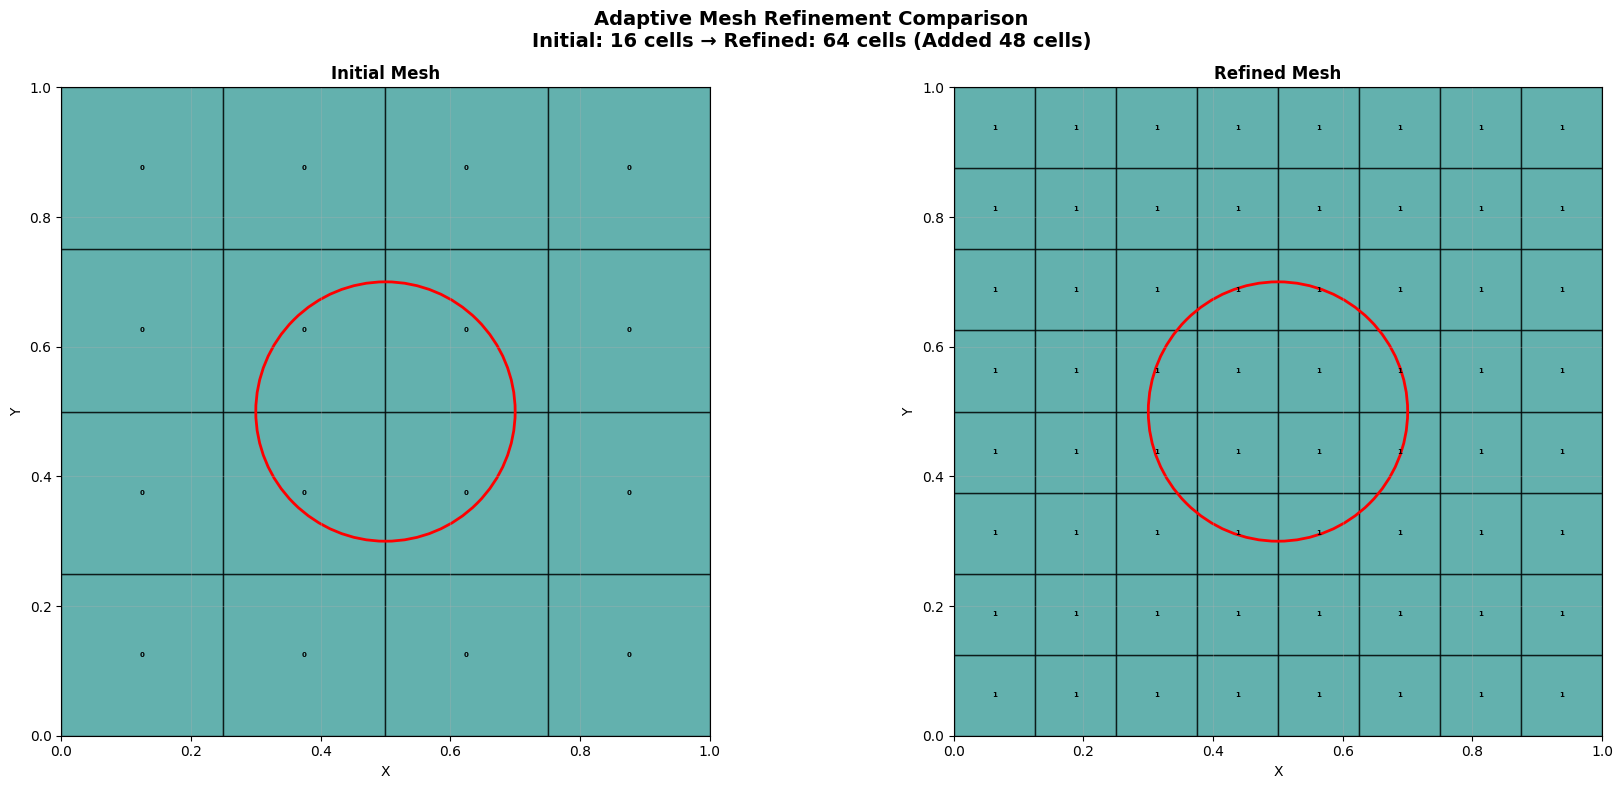

All visualizations completed!


/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


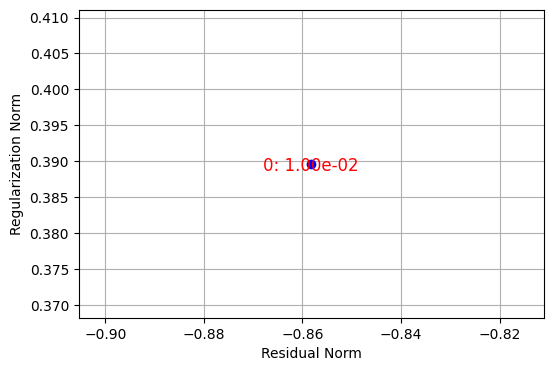

第 1 次迭代的train误差：
第 1 次迭代的泛化误差：


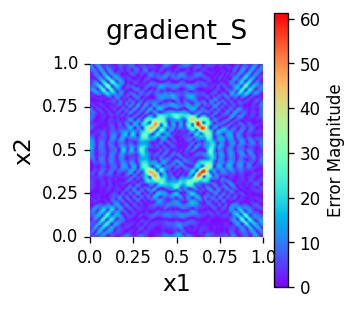

S_l_inf= 3.0649774178281457 S_L_2= 0.14093848785662905 S_l_2= 0.39937769774832826


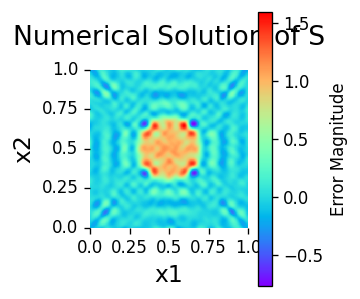

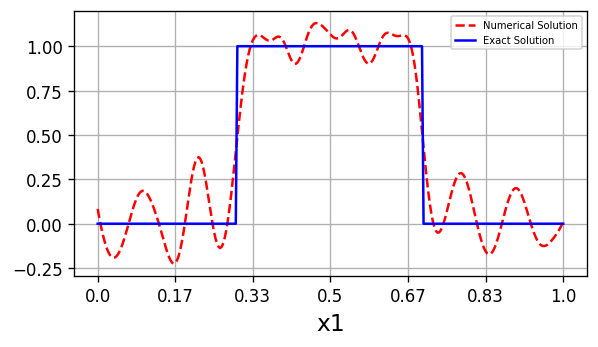

第 1 次自适应网格细分 (Diff Criterion)...
Generating visualizations...
1. Plotting mesh comparison...


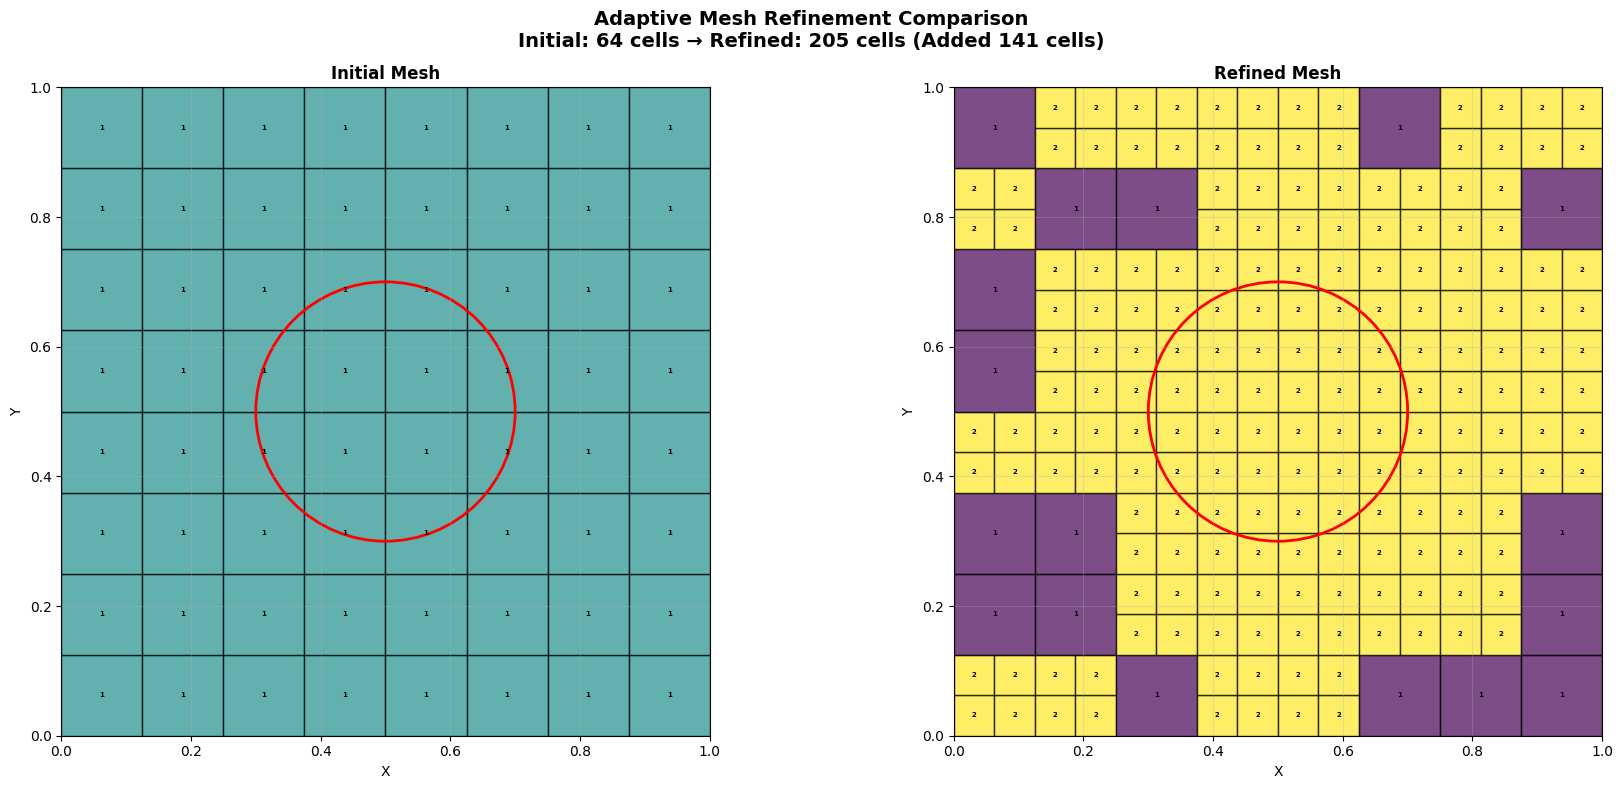

All visualizations completed!


/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


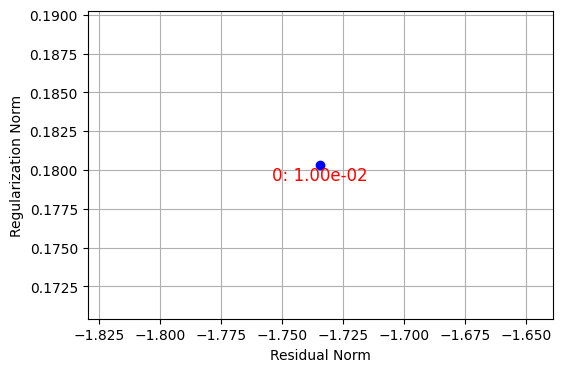

第 2 次迭代的train误差：
第 2 次迭代的泛化误差：


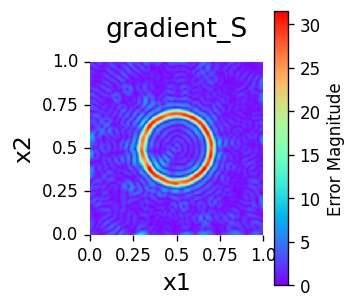

S_l_inf= 1.5752030634617866 S_L_2= 0.06834078110369443 S_l_2= 0.19365741916630172


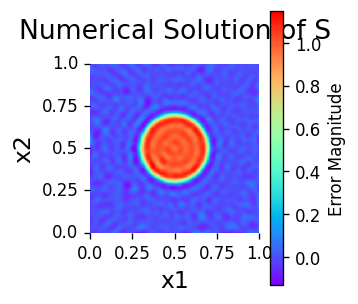

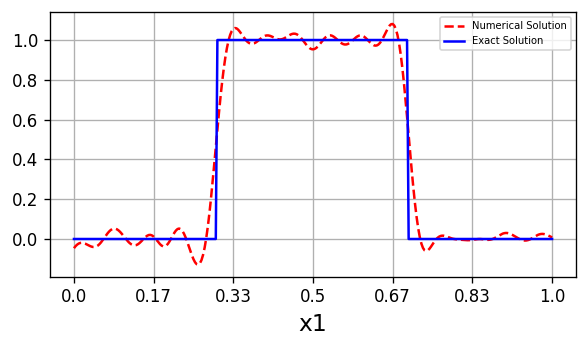

第 2 次自适应网格细分 (Diff Criterion)...
Generating visualizations...
1. Plotting mesh comparison...


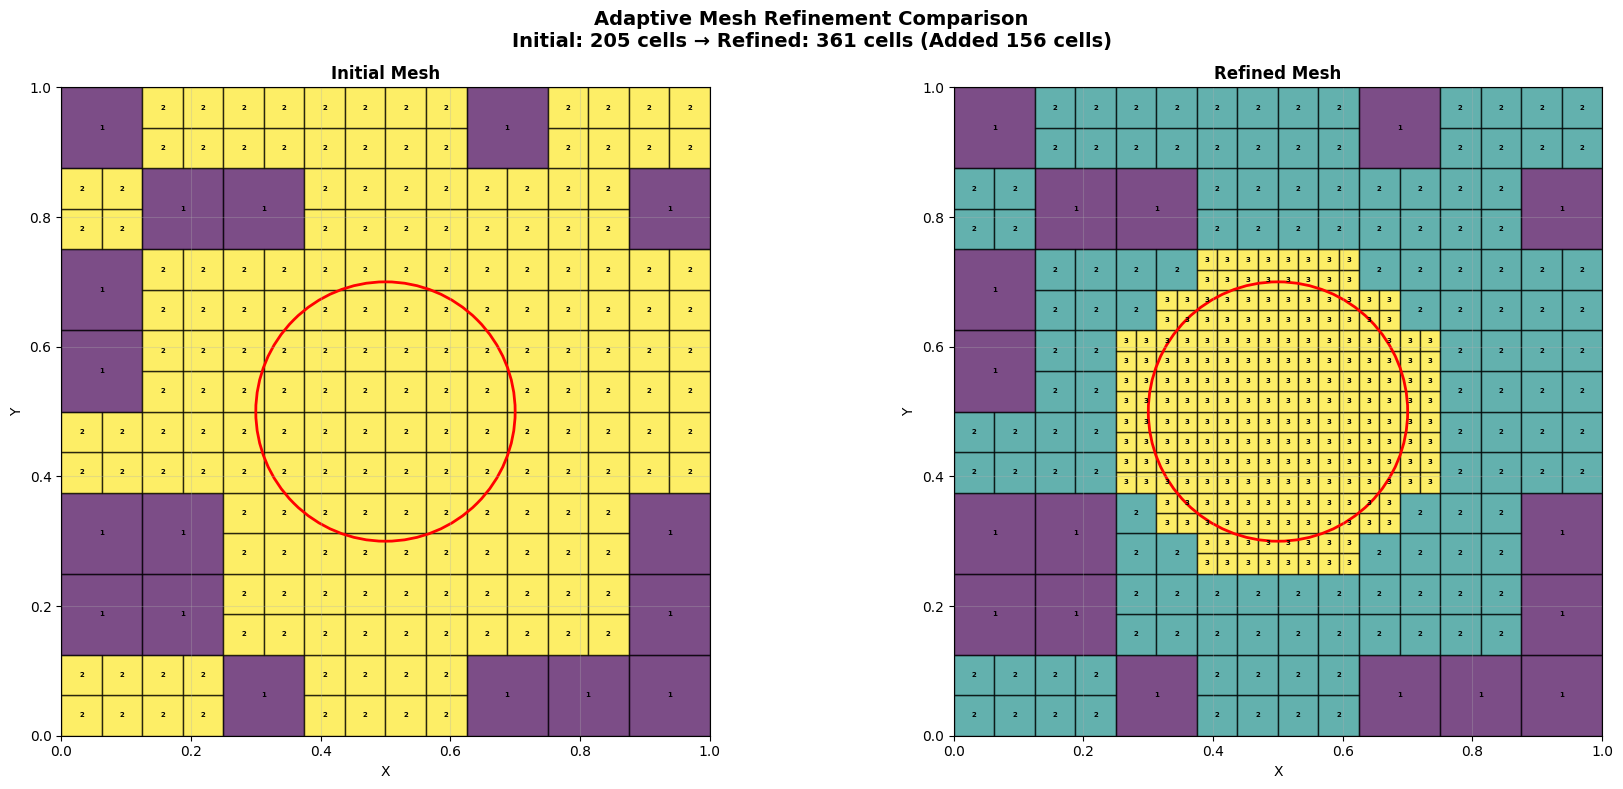

All visualizations completed!


/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


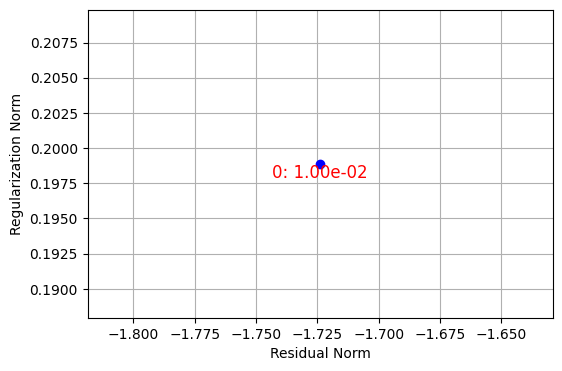

第 3 次迭代的train误差：
第 3 次迭代的泛化误差：


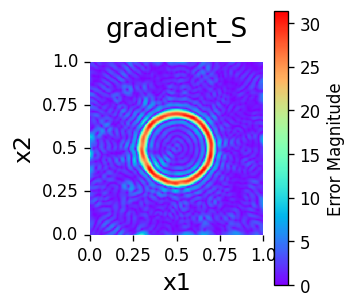

S_l_inf= 1.5255197109208107 S_L_2= 0.06843364474270859 S_l_2= 0.19392056706094732


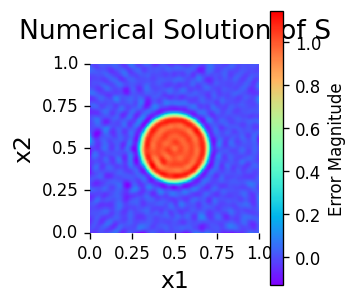

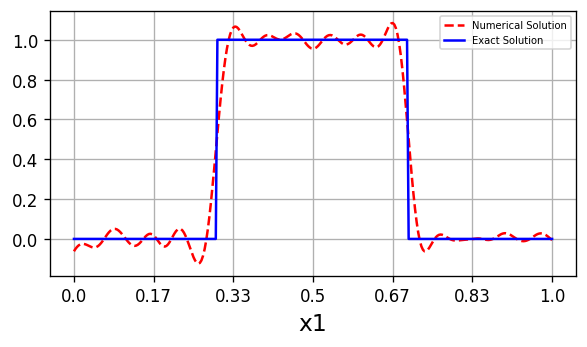

第 3 次自适应网格细分 (Diff Criterion)...
Generating visualizations...
1. Plotting mesh comparison...


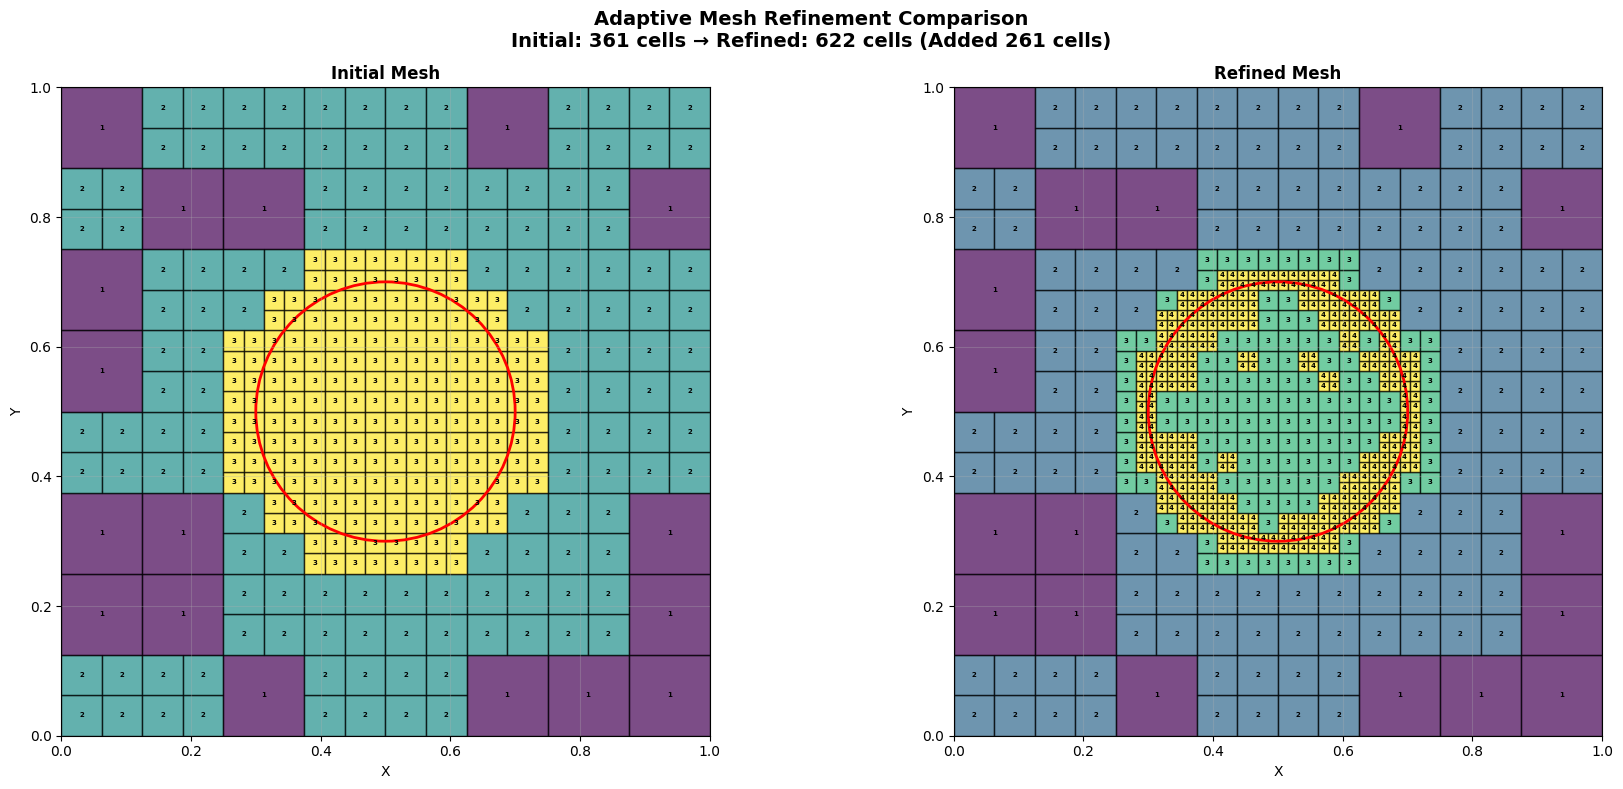

All visualizations completed!


/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


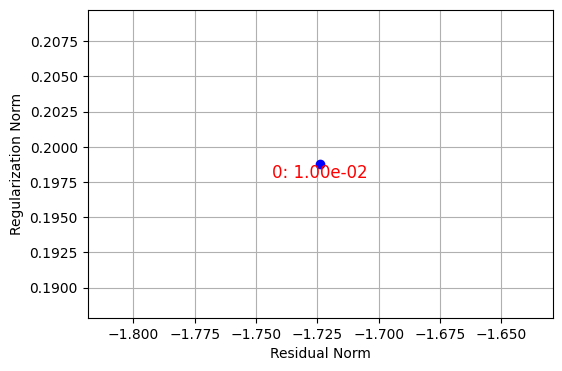

第 4 次迭代的train误差：
第 4 次迭代的泛化误差：


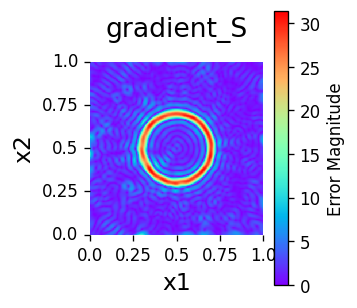

S_l_inf= 1.525339131076291 S_L_2= 0.06843286105842611 S_l_2= 0.19391834633310173


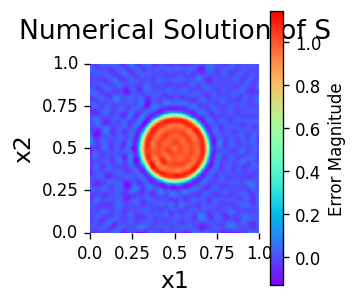

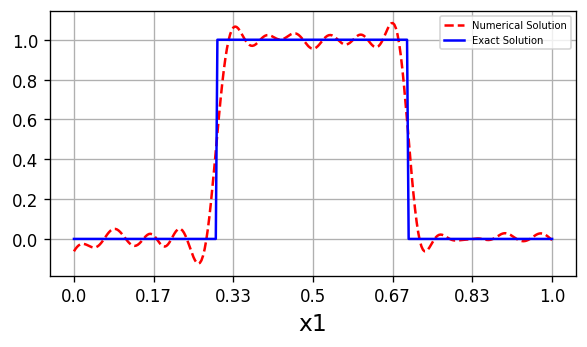

在第 4 次迭代结束


In [5]:
iter_int= 5
Ix,Iy=4,4  #x方向网格点
delta=10**(-3)
nx=3
lamb_regu=np.logspace(-2,-1,1)
Qx,Qy=150,150
max_level=4
current_maxiter=1
af="Tanh"
refine_threshold_S=[5e-5, 1e-4, 5e-4, 1e-3, 5e-3] #刚开始阈值小多细分，后面阈值大少细分
#refine_threshold_grad=[1e-7, 1e-7, 8e-7, 8e-7, 8e-7] #刚开始阈值小多细分，后面阈值大少细分
#refine_threshold_grad=[1e-8, 1e-8, 1e-7, 1e-7, 1e-6] #刚开始阈值小多细分，后面阈值大少细分
refine_threshold_grad=[5e-9, 1e-8, 5e-8, 1e-7, 5e-7]
refine_threshold_noise=[1e-2,1e-2,1e-2,1e-2,1e-2,1e-2]
# using main_fix.ada_int_fix
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_l2,S_num_store=main_fix.ada_int_fix(iter_int,delta,cells,nx,models,M,af,kk,F,tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_low,r_upper,center_true,r_true,f_circle,points_b,lamb_regu,Qx,Qy,device,cupy_device,refine_threshold_S,refine_threshold_grad,refine_threshold_noise,current_maxiter,max_level)

In [6]:
len(cells_store[-1])

622

In [ ]:
#保存cell_stores
import pickle
with open('./MA_RFM=5%/M=3200*2_5%/cells_store.pkl', 'wb') as f:
    pickle.dump(cells_store, f)

In [ ]:
import pickle
#加载数据
with open('./MA_RFM=5%/M=3200*2_5%/cells_store.pkl', 'rb') as f:
    cells_store = pickle.load(f)

In [9]:
import sys
sys.path.append(r"/data5/store1/hxw/inverse_source/AMain")  # 绝对路径
# 或
sys.path.append(r"../../AMain")  # 相对路径（从当前 notebook 位置）

import bound_detect
reload(bound_detect)

<module 'bound_detect' from '/data5/store1/hxw/inverse_source/Kernet/2d_inverse_source_Kernet_DiriNeu_objects/one_object_支集为常数_中间/./main_code/main_code2/bound_detect.py'>

Number of detected clusters: 1
Cluster 0: AR=1.00
  Res_Rect=0.097 vs Res_Ellip=0.018
  -> Winner: Circle
Cluster 0: Lx=0.400, Ly=0.400, AR=1.00
  -> Decision: Circle (Sigmoid)


/data5/store1/hxw/inverse_source/Kernet/2d_inverse_source_Kernet_DiriNeu_objects/one_object_支集为常数_中间/./main_code/main_code2/bound_detect.py:429: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


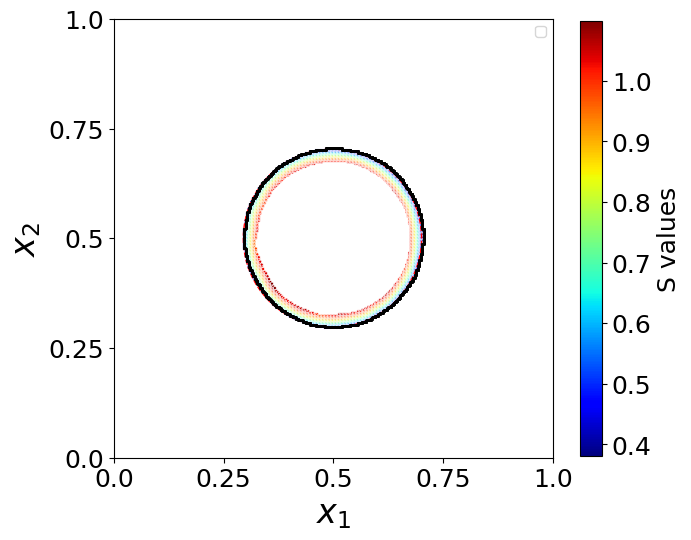

<Figure size 640x480 with 0 Axes>

In [ ]:
from importlib import reload
reload(bound_detect)
x=np.linspace(tau_x_min,tau_x_max,301)
y=np.linspace(tau_y_min,tau_y_max,301)
X,Y=np.meshgrid(x,y)
eps_cluster=0.02
mini_samples=20
para_abs=3
para_grad=3
results=bound_detect.detect_shape(g_S,X.T,Y.T,tau_x_min,tau_x_max,tau_y_min,tau_y_max,para_abs,para_grad,eps_cluster,mini_samples,S_num_store[-1],output_directory="./MA_RFM=5%/M=3200*2_5%", output_filename="plot.png")

In [11]:
results

[{'cluster_id': 0,
  'shape': 'Circle',
  'params': {'center': array([0.49791667, 0.49986619]),
   'radius': np.float64(0.2030567137053538)},
  'profile': 'Sigmoid'}]

In [12]:
center=results[0]['params']['center']
r = results[0]['params']['radius']

In [16]:
import net_2D_fix2

r_min=r*(1-0.1)
r_max=r*(1+0.05)
K_min=1000
K_max=20000
b1_min=-center[0]*(1+0.05)
b1_max=-center[0]*(1-0.05)
b2_min=-center[1]*(1+0.05)
b2_max=-center[1]*(1-0.05)
models1=models
models2=net_2D_shape.local_rep(2,1,1,M,tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_min,r_max,b1_min,b1_max,b2_min,b2_max,[],[],[],[],[],[],[],[],K_min,K_max,R_m_for_init=R_m,af="sigmoid",Shape="circle",device=device).to(device)
#models2= net_2D_shape.pre_define(Nx,Ny,M,R_m,"sigmoid",tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_min,r_max,b1_min,b1_max,b2_min,b2_max,[],[],[],[],[],[],[],[],K_min,K_max,"circle",device)
af="mix"
sum_mat,all_g_p1,all_g_n,cells_copy1,rrr,sss=ass_grad.mat_assemble(cells_store[-1],models1,models2,[],"mix","circle",[],kk,0,points_b,0,device,cupy_device)

/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


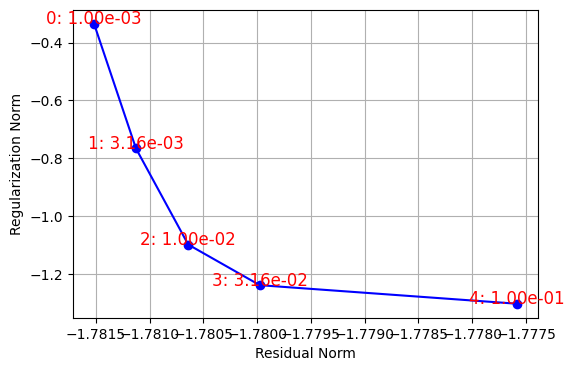

In [17]:
lamb_regu=np.logspace(-3,-1,5,endpoint=True)
res,reg_norm,w_store=org_m.L_curve(sum_mat,F,[],[],[],lamb_regu,"linear",device,cupy_device) #先进行求解

lamb: 0.0001
S_l_inf= 1.563850901803476 S_L_2= 0.04748519474735748 S_l_2= 0.13455889901857382


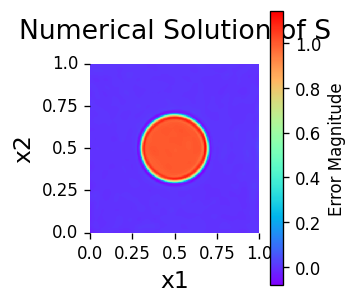

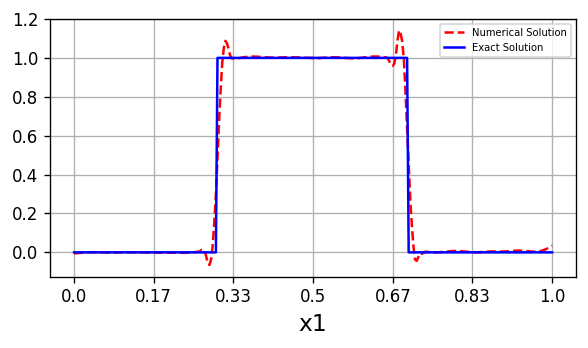

In [26]:
lamb=lamb_regu[2]**2
print('lamb:',lamb)
S_test_num,S_test_true,S_l_inf1,S_l_21,g_SS=error_general_ada.test(models1,models2,[],M,Qx,Qy,w_store[:,2
                                                                                                      ],af,"circle",[],True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],center_true,r_true,f_circle,0,device)

In [ ]:
torch.save(models1,"./MA_RFM=5%/M=3200*2_5%/models1_3200.pth")

In [ ]:
torch.save(models2,"./MA_RFM=5%/M=3200*2_5%/models1_sig_33_3200.pth")

In [ ]:
np.save("./MA_RFM=5%/M=3200*2_5%/g_S",g_S)
np.save("./MA_RFM=5%/M=3200*2_5%/S_l2",S_l2)
np.save("./MA_RFM=5%/M=3200*2_5%/S_num_store",S_num_store)
np.save("./MA_RFM=5%/M=3200*2_5%/S_num_MA-RFM_800",S_test_num)
np.save("./MA_RFM=5%/M=3200*2_5%/all_mat",sum_mat)
np.save("./MA_RFM=5%/M=3200*2_5%/w_store",w_store)
np.save("./MA_RFM=5%/M=3200*2_5%/F_mea_b",F_mea_b_circle)
np.save("./MA_RFM=5%/M=3200*2_5%/F_mea_db_x1",F_mea_db_x1_circle)
np.save("./MA_RFM=5%/M=3200*2_5%/F_mea_db_x2",F_mea_db_x2_circle)

In [30]:
parameters0 = {
    "I_grid":Ix,
    "gauss_n":nx,
    "number_gene":number_gene,
    "noise":eps,
    "k": kk,
    "M0": M,
    "M1": M,
    "Tanh_Rm":20,
    "Gauss_R_m": R_m,
    "refinement_stats_store":refinement_stats_store,
    "points_number_ada:":point_number,
    "center":center,
    "r":r,
    "r_min": r_min,
    "r_max": r_max,
    "b1_min": b1_min,
    "b1_max": b1_max,
    "b2_min": b2_min,
    "b2_max": b2_max,
    "K_min": K_min,
    "K_max": K_max,
}

In [ ]:
import pickle # 导入 pickle 模块
output_pickle_file = "./MA_RFM=5%/M=3200*2_5%/parameters.pkl"
with open(output_pickle_file, 'wb') as f: # 'wb' for write binary
    pickle.dump(parameters0, f)

In [32]:
## 帮我打印 n_integral:len(cell_stores[-1])*9, center[0],width,height, center[1], r, S_l2[-1], lamb_regu**2, S_l21
#打印成列表形式 
n_integral=len(cells_store[-1])*9
print('n_integral:',n_integral)
print('center:',center)


print('r:',r)
print('S_l2[-1]:',S_l2[-1])
print('lamb_regu:',lamb)
print('S_l21:',S_l_21)

n_integral: 5598
center: [0.49791667 0.49986619]
r: 0.2030567137053538
S_l2[-1]: 0.19391834633310173
lamb_regu: 0.0001
S_l21: 0.13455889901857382
